
# Python for (open) Neuroscience  
### Practical 2.2 — *Numpy: Operations with arrays*
#### Module 02 - Scientific stack

**How to use this notebook**
- Complete the `____` blanks.
- Keep the starter code structure whenever possible.
- Run each code cell with **Shift+Enter**


In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)


## 1. Reshape a flat signal into trials

In [ ]:
# You recorded 48 values from an experiment with:
# - 6 trials
# - 8 samples per trial
#
# Task:
# 1) Create a 1D array with values from 0 to 47.
# 2) Reshape it into a 2D array of shape (6, 8).
# 3) Print the shape.

raw = np.arange(48)
trials = raw.reshape(6, 8)

print(trials)
print("shape:", trials.shape)


[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]]
shape: (6, 8)


## 2. Reorder dimensions with transpose

In [ ]:
# Suppose an array has shape (subjects, conditions, timepoints) = (2, 3, 4).
#
# Task:
# 1) Create the array with np.arange and reshape.
# 2) Reorder it to (conditions, subjects, timepoints).
# 3) Check the new shape.

arr = np.arange(24).reshape(2,3,4)
reordered = np.transpose(arr, axes=(1,0,2))

print("original shape:", arr.shape)
print("reordered shape:", reordered.shape)


original shape: (2, 3, 4)
reordered shape: (3, 2, 4)


## 3. Concatenate vs stack

In [ ]:
# Create two matrices of shape (3, 4):
# - A full of zeros
# - B full of ones
#
# Task:
# 1) Concatenate them along axis 0
# 2) Concatenate them along axis 1
# 3) Stack them along a new axis 0
# 4) Print the three resulting shapes

A = np.zeros((3,4))
B = np.ones((3,4))

cat0 = np.concatenate([A,B], axis=0)
cat1 = np.concatenate([A,B], axis=1)
stack0 = np.stack([A,B], axis=0)

print("cat axis=0:", cat0.shape)
print("cat axis=1:", cat1.shape)
print("stack axis=0:", stack0.shape)


cat axis=0: (6, 4)
cat axis=1: (3, 8)
stack axis=0: (2, 3, 4)



## 4. Fix broadcasting with a singleton dimension

A **singleton dimension** is a dimension of size 1. It is often added with `reshape(..., 1)` or `None`/`np.newaxis` to make shapes compatible for broadcasting.


In [ ]:
# You have a matrix with shape (5, 4) and a vector with shape (5,).
# Direct addition fails because NumPy compares shapes from the right.
#
# Task:
# 1) Create both arrays.
# 2) Reshape the vector so it can be added to each row.
# 3) Compute the result.

M = np.arange(20).reshape(5, 4)
v = np.arange(5)

v_fixed = v.reshape(5,1)
result = M + v_fixed

print("M shape:", M.shape)
print("v_fixed shape:", v_fixed.shape)
print(result)


M shape: (5, 4)
v_fixed shape: (5, 1)
[[ 0  1  2  3]
 [ 5  6  7  8]
 [10 11 12 13]
 [15 16 17 18]
 [20 21 22 23]]



## 5. Row means with `keepdims=True`

`keepdims=True` keeps the reduced axis with length 1 instead of removing it.  
This is useful when you want to subtract or divide by the result using broadcasting.


In [ ]:

# Create a random matrix of shape (4, 6).
#
# Task:
# 1) Compute the mean of each row with keepdims=True.
# 2) Subtract the row mean from the original matrix.
# 3) Verify that the centered rows have mean ~0.

X = np.random.normal(loc=10, scale=2, size=(4, 6))

row_mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - row_mean
check = np.mean(X_centered, axis=1)

print("row_mean shape:", row_mean.shape)
print("means after centering:", check)


row_mean shape: (4, 1)
means after centering: [ 2.96059473e-16  5.92118946e-16 -2.96059473e-16 -7.40148683e-16]



## 6. Find extreme positions with `argmax()` and `argmin()`

- `np.argmax()` returns the **index of the maximum value**.
- `np.argmin()` returns the **index of the minimum value**.

They can work on the whole array or along a chosen axis.


In [ ]:
# Create a matrix of reaction times for 5 subjects across 8 trials.
#
# Task:
# 1) Find, for each subject (row), the index of the slowest trial.
# 2) Find, for each subject, the index of the fastest trial.
# 3) Extract the slowest RT value of each subject using advanced indexing.

rt = np.random.uniform(250, 900, size=(5, 8))
slowest_idx = np.argmax(rt, axis=1)
fastest_idx = np.argmin(rt, axis=1)

row_idx = np.arange(rt.shape[0])
slowest_values = rt[row_idx, slowest_idx]

print("slowest idx:", slowest_idx)
print("fastest idx:", fastest_idx)
print("slowest values:", slowest_values)


slowest idx: [0 2 0 7 1]
fastest idx: [7 0 7 6 5]
slowest values: [797.9145636  897.54592048 826.28703698 873.83471895 811.46325493]


## 7. NaN-aware statistics

In [ ]:
# The matrix below contains missing values encoded as np.nan.
#
# Task:
# 1) Compute the mean of each column ignoring NaNs.
# 2) Compute the total sum of the whole matrix ignoring NaNs.
# 3) Count how many NaNs are present.

Y = np.array([
    [1.0,  2.0,  np.nan, 4.0],
    [2.0,  np.nan, 6.0,   8.0],
    [np.nan, 1.0, 5.0,   7.0],
])

col_mean = np.nanmean(Y, axis=0)
total = np.nansum(Y)
n_nan = np.sum(np.isnan(Y))

print("column means:", col_mean)
print("total:", total)
print("number of NaNs:", n_nan)


column means: [1.5        1.5        5.5        6.33333333]
total: 36.0
number of NaNs: 3



## 8. Conditional replacement with `np.where()`

`np.where(condition, value_if_true, value_if_false)` selects values element by element based on a boolean condition.


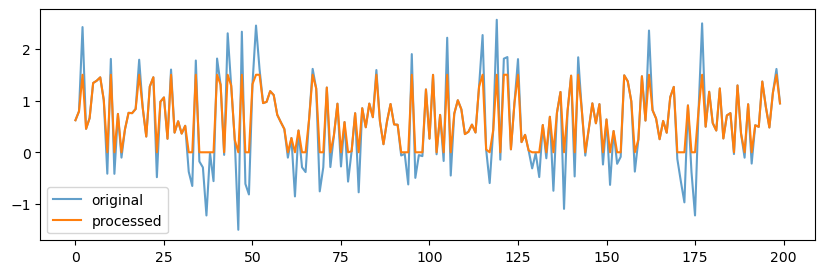

In [ ]:
# Simulate a noisy signal.
#
# Task:
# 1) Replace all negative values with 0 using np.where.
# 2) Replace all values above 1.5 with 1.5 (hard ceiling) using np.where.
# 3) Plot original and processed signal.

signal = np.random.normal(0.5, 0.8, size=200)

nonnegative = np.where(signal<0, 0 , signal)
clipped = np.where(nonnegative>1.5, 1.5, nonnegative)

plt.figure(figsize=(10, 3))
plt.plot(signal, label="original", alpha=0.7)
plt.plot(clipped, label="processed")
plt.legend()
plt.show()


## 9. Unique labels and counts

In [ ]:
# You have condition labels from repeated trials.
#
# Task:
# 1) Use np.unique to find all unique labels.
# 2) Also get how many times each label appears.
# 3) Print the result in a readable way.

labels = np.array([2, 1, 3, 2, 1, 2, 3, 3, 3, 1, 2, 2])

unique_labels, counts = np.unique(labels, return_counts=True)

for lab, cnt in zip(unique_labels, counts):
    print(f"label {lab}: {cnt} trials")


label 1: 3 trials
label 2: 5 trials
label 3: 4 trials


## 10. Detect jumps with `np.diff()` and reconstruct with `np.cumsum()`

In [ ]:
# A cumulative position trace is stored below.
#
# Task:
# 1) Compute the step-to-step differences.
# 2) Reconstruct the original signal starting from the first value.
# 3) Check that reconstruction matches the original.

position = np.array([10, 13, 15, 20, 18, 21, 21, 25])

steps = np.diff(position)
reconstructed = position[0] + np.cumsum(steps)
reconstructed = np.insert(reconstructed, 0, position[0])

print("steps:", steps)
print("reconstruction correct:", np.all(position == reconstructed))

steps: [ 3  2  5 -2  3  0  4]
reconstruction correct: True


## 11. Broadcasting a baseline across trials

In [ ]:
# Imagine fluorescence data of shape (trials, timepoints) = (12, 50).
# We want to subtract, from each trial, its baseline computed over the first 5 timepoints.
#
# Task:
# 1) Create the data matrix.
# 2) Compute one baseline value per trial using the first 5 columns.
# 3) Keep dimensions so subtraction broadcasts correctly.
# 4) Create baseline-corrected data.

F = np.random.normal(loc=100, scale=5, size=(12, 50))

baseline = np.mean(F[:, :5], axis=1, keepdims=True)
F_corr = F - baseline

print("baseline shape:", baseline.shape)
print("corrected shape:", F_corr.shape)


baseline shape: (12, 1)
corrected shape: (12, 50)


## 12. Combine `argmax()` with advanced indexing

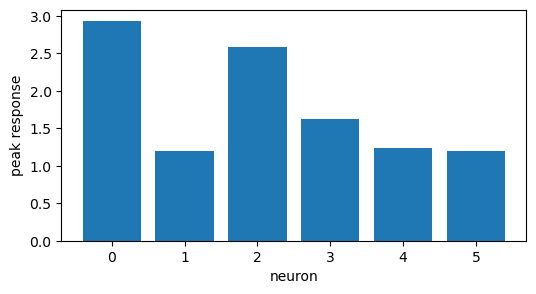

In [ ]:
# Each row is a neuron, each column a timepoint.
#
# Task:
# 1) Create a random response matrix of shape (6, 20).
# 2) Find the peak time index for each neuron.
# 3) Extract the peak response value for each neuron.
# 4) Plot the peak values as a bar plot.

responses = np.random.normal(size=(6, 20))

peak_idx = np.argmax(responses, axis=1)
rows = np.arange(responses.shape[0])
peak_values = responses[rows, peak_idx]

plt.figure(figsize=(6, 3))
plt.bar(rows, peak_values)
plt.xlabel("neuron")
plt.ylabel("peak response")
plt.show()



## 13. Row-wise z-scoring with `keepdims`

This is a classic vectorization exercise.

For each row:
\[
z = 
rac{x - \mu}{\sigma}
\]

Compute the row-wise mean and standard deviation once, then rely on broadcasting.


In [ ]:
# Task:
# 1) Create a matrix of shape (7, 30).
# 2) Compute row-wise mean and std with keepdims=True.
# 3) Build a row-wise z-scored version of the matrix.
# 4) Check that each row now has mean about 0 and std about 1.

X = np.random.normal(loc=5, scale=3, size=(7, 30))

mu = np.mean(X, axis=1, keepdims=True)
sigma = np.std(X, axis=1, keepdims=True)
Z = (X - mu) / sigma

print("row means:", np.round(np.mean(Z, axis=1), 6))
print("row stds:", np.round(np.std(Z, axis=1), 6))


row means: [-0.  0.  0. -0.  0. -0.  0.]
row stds: [1. 1. 1. 1. 1. 1. 1.]


## 14. Multi-step challenge: best condition per subject

In [ ]:

# You have a dataset with shape:
# (subjects, conditions, repetitions) = (4, 3, 5)
#
# Task:
# 1) Create the array with random values.
# 2) Compute the mean response for each subject and condition over repetitions.
# 3) For each subject, find which condition has the highest mean response.
# 4) Extract that best mean response value.
#
# Hint: after averaging over repetitions, you should have shape (4, 3).

data = np.random.normal(loc=0, scale=1, size=(4, 3, 5))

mean_resp = np.mean(data, axis=2)
best_cond_idx = np.argmax(mean_resp, axis=1)
subject_idx = np.arange(mean_resp.shape[0])
best_values = mean_resp[subject_idx, best_cond_idx]

print("mean_resp shape:", mean_resp.shape)
print("best condition per subject:", best_cond_idx)
print("best mean values:", best_values)


mean_resp shape: (4, 3)
best condition per subject: [0 1 1 2]
best mean values: [0.47363742 0.21028981 0.70025421 0.25843954]


## 15. Final challenge: normalize, threshold, summarize

active counts: [ 9 10  6 10  9  6 12  9  8 10]
row with most supra-threshold samples: 6


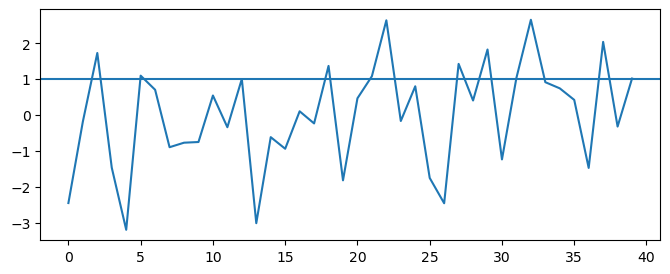

In [ ]:
# Build a mini analysis pipeline.
#
# Task:
# 1) Create a matrix of shape (10, 40) representing 10 signals across 40 samples.
# 2) Normalize each row by subtracting its row mean (use keepdims=True).
# 3) Create a boolean matrix marking values > 1.0 after normalization.
# 4) Count, for each row, how many supra-threshold samples there are.
# 5) Find the row index with the largest count.
#
# Extra: plot that row.

signals = np.random.normal(loc=2, scale=1.2, size=(10, 40))

row_mean = np.mean(signals, axis=1, keepdims=True)
signals_centered = signals - row_mean
active = signals_centered > 1.0
active_counts = np.sum(active, axis=1)
best_row = np.argmax(active_counts)

print("active counts:", active_counts)
print("row with most supra-threshold samples:", best_row)

plt.figure(figsize=(8, 3))
plt.plot(signals_centered[best_row])
plt.axhline(1.0)
plt.show()
